In [2]:
import importlib.util
import sys
import subprocess

def check_installation_and_install(package_name):
    spec = importlib.util.find_spec(package_name)
    if spec is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
    else:
        print(package_name + " is installed");

check_installation_and_install("pandas")
check_installation_and_install("matplotlib")
check_installation_and_install("numpy")
check_installation_and_install("wfdb")

pandas is installed
matplotlib is installed
numpy is installed
wfdb is installed


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score
from sklearn import linear_model
from sklearn.tree import DecisionTreeClassifier 
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV

import tensorflow as tf

## Load Data

In [2]:
file_directory = "./Cleaned_Data"

# Load dataset from a CSV file
df = pd.read_csv(os.path.join(file_directory,"Cleaned_Data.csv"))

df = df.drop(columns = ['Unnamed: 0'])

# Display the first few rows of the dataset
df.head()

,RXPACC,FP_IDX,CIR746,CIR740,CIR749,CIR_PWR,CIR750,CIR575,CIR326,CIR333,CIR349,CIR350,CIR246,NLOS,RANGE
0,611.0,745.0,6102.0,266.0,9621.0,11855.0,8303.0,106.0,150.0,182.0,179.0,215.0,284.0,0.0,3.90
1,447.0,749.0,194.0,10.0,1840.0,18968.0,5244.0,245.0,263.0,247.0,123.0,299.0,230.0,0.0,0.66
2,723.0,746.0,1212.0,500.0,4489.0,14699.0,2992.0,73.0,172.0,265.0,205.0,180.0,314.0,1.0,7.86
3,1024.0,750.0,292.0,241.0,1424.0,8748.0,2907.0,418.0,213.0,250.0,157.0,345.0,317.0,1.0,3.48
4,276.0,746.0,11949.0,280.0,16162.0,11380.0,19583.0,185.0,68.0,240.0,42.0,338.0,152.0,0.0,1.19


## Split data 

In [3]:
original_df = df

X = original_df.drop(['NLOS'], axis=1)
y = original_df['NLOS']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# print(X_train.describe())

# Classification of NLOS and LOS data

## Decision Tree Classification

In [8]:
from sklearn.model_selection import cross_val_score
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Define parameter ranges
depth_range = range(1, 21)  # Testing max_depth from 1 to 20
n_estimators_range = [10, 50, 100, 200]  # Testing different n_estimators for RF

# Store results
dtc_results = {}
rfc_results = {}

# Decision Tree: Testing different max_depth values
for depth in depth_range:
    dtc = DecisionTreeClassifier(criterion="entropy", max_depth=depth, random_state=42)
    scores = cross_val_score(dtc, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)  # Use all CPU cores
    dtc_results[depth] = np.mean(scores)

# Random Forest: Testing different n_estimators and max_depth
for n in n_estimators_range:
    for depth in depth_range:
        rfc = RandomForestClassifier(n_estimators=n, max_depth=depth, random_state=42, n_jobs=-1)  # Use all CPU cores
        scores = cross_val_score(rfc, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)  # Use all CPU cores
        rfc_results[(n, depth)] = np.mean(scores)

# Get the best parameters
best_dtc_depth = max(dtc_results, key=dtc_results.get)
best_rfc_params = max(rfc_results, key=rfc_results.get)

print(f"Best Decision Tree max_depth: {best_dtc_depth} with accuracy {dtc_results[best_dtc_depth]:.4f}")
print(f"Best Random Forest n_estimators: {best_rfc_params[0]}, max_depth: {best_rfc_params[1]} with accuracy {rfc_results[best_rfc_params]:.4f}")


Best Decision Tree max_depth: 9 with accuracy 0.8774
Best Random Forest n_estimators: 200, max_depth: 19 with accuracy 0.8926


## KNN

k=1, Training Accuracy: 1.0000, Test Accuracy: 0.7167
k=2, Training Accuracy: 0.8465, Test Accuracy: 0.7370
k=3, Training Accuracy: 0.8587, Test Accuracy: 0.7492
k=4, Training Accuracy: 0.8209, Test Accuracy: 0.7543
k=5, Training Accuracy: 0.8278, Test Accuracy: 0.7536
k=6, Training Accuracy: 0.8072, Test Accuracy: 0.7575
k=7, Training Accuracy: 0.8128, Test Accuracy: 0.7570
k=10, Training Accuracy: 0.7956, Test Accuracy: 0.7640
k=11, Training Accuracy: 0.8001, Test Accuracy: 0.7659
k=12, Training Accuracy: 0.7911, Test Accuracy: 0.7679
k=13, Training Accuracy: 0.7940, Test Accuracy: 0.7694
k=14, Training Accuracy: 0.7878, Test Accuracy: 0.7675
k=15, Training Accuracy: 0.7907, Test Accuracy: 0.7678
k=16, Training Accuracy: 0.7866, Test Accuracy: 0.7670
k=17, Training Accuracy: 0.7878, Test Accuracy: 0.7671
k=18, Training Accuracy: 0.7828, Test Accuracy: 0.7680
k=19, Training Accuracy: 0.7848, Test Accuracy: 0.7695
k=20, Training Accuracy: 0.7814, Test Accuracy: 0.7683
k=25, Training Ac

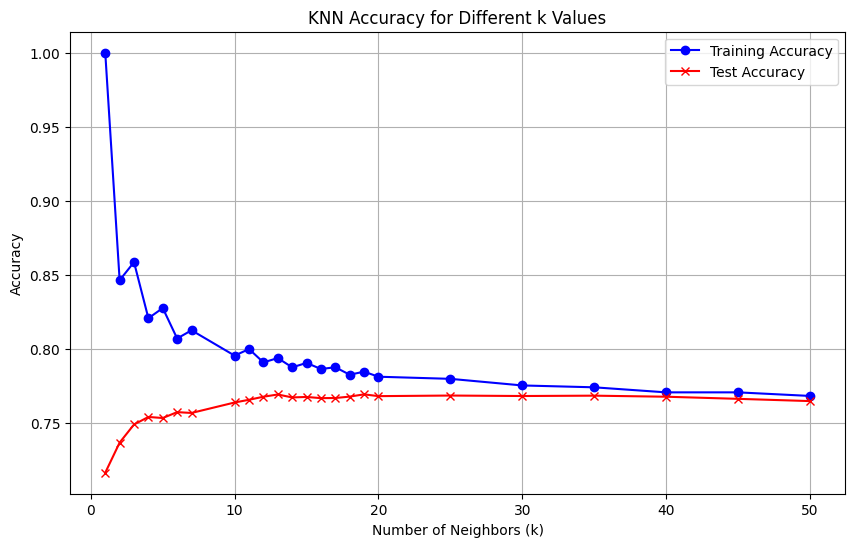

In [ ]:
numNeighbors = [1, 2, 3, 4, 5, 6, 7, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 25, 30, 35, 40, 45, 50]
trainAcc = []
testAcc = []

for k in numNeighbors:
    clf1 = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=2)
# Train the model on the training data
    clf1.fit(X_train, y_train)
# Make predictions using the trained model
    Y_predTrain = clf1.predict(X_train)
    Y_predTest = clf1.predict(X_test)

# Calculate the accuracy of the model
    train_accuracy = accuracy_score(y_train, Y_predTrain)
    test_accuracy = accuracy_score(y_test, Y_predTest)

    trainAcc.append(accuracy_score(y_train, Y_predTrain))
    testAcc.append(accuracy_score(y_test, Y_predTest))

    print(f'k={k}, Training Accuracy: {train_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}')    

plt.figure(figsize=(10, 6))
# Plot data for visualization
plt.plot(numNeighbors, trainAcc, label='Training Accuracy', marker='o', color='blue')
plt.plot(numNeighbors, testAcc, label='Test Accuracy', marker='x', color='red')

plt.title('KNN Accuracy for Different k Values')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## Neural Network

hidden_layer_sizes=(5, 5), Training Accuracy: 0.8544, Test Accuracy: 0.8511
hidden_layer_sizes=(6, 6), Training Accuracy: 0.8383, Test Accuracy: 0.8352
hidden_layer_sizes=(7, 7), Training Accuracy: 0.8596, Test Accuracy: 0.8556
hidden_layer_sizes=(10, 10), Training Accuracy: 0.8554, Test Accuracy: 0.8544
hidden_layer_sizes=(20, 20), Training Accuracy: 0.8555, Test Accuracy: 0.8570
hidden_layer_sizes=(30, 30), Training Accuracy: 0.8566, Test Accuracy: 0.8549
hidden_layer_sizes=(40, 40), Training Accuracy: 0.8612, Test Accuracy: 0.8575
hidden_layer_sizes=(5, 5, 5), Training Accuracy: 0.8425, Test Accuracy: 0.8398
hidden_layer_sizes=(6, 6, 6), Training Accuracy: 0.8475, Test Accuracy: 0.8442
hidden_layer_sizes=(7, 7, 7), Training Accuracy: 0.8521, Test Accuracy: 0.8507
hidden_layer_sizes=(10, 10, 10), Training Accuracy: 0.8559, Test Accuracy: 0.8536
hidden_layer_sizes=(20, 20, 10), Training Accuracy: 0.8536, Test Accuracy: 0.8532
hidden_layer_sizes=(30, 30, 30), Training Accuracy: 0.8593,

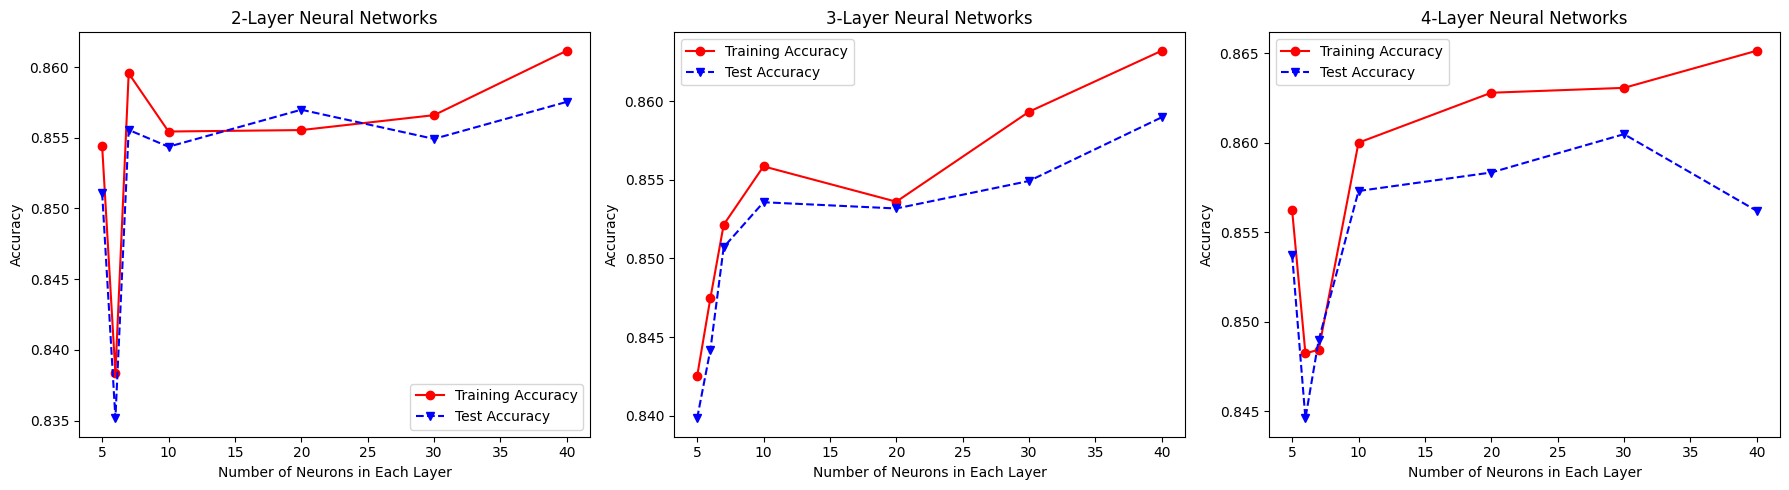

In [5]:
hidden_layer_sizes = [
    (5, 5), (6, 6), (7, 7), (10, 10), (20, 20), (30, 30), (40, 40),  # 2 layers
    (5, 5, 5), (6, 6, 6), (7, 7, 7), (10, 10, 10), (20, 20, 10), (30, 30, 30), (40, 40, 40),  # 3 layers
    (5, 5, 5, 5), (6, 6, 6, 6), (7, 7, 7, 7), (10, 10, 10, 10), (20, 20, 20, 20), (30, 30, 30, 30), (40, 40, 40, 40)  # 4 layers
]

# Initialize lists for storing accuracy
trainAcc = []
testAcc = []

for k in hidden_layer_sizes:
    clf6 = MLPClassifier(solver='adam', hidden_layer_sizes=k, learning_rate_init=0.0005,
                         activation='relu', random_state=1, max_iter=2000, batch_size=32)
    
    # Train model
    clf6.fit(X_train, y_train)
    
    # Predictions
    Y_predTrain = clf6.predict(X_train)
    Y_predTest = clf6.predict(X_test)
    
    # Store accuracy
    trainAcc.append(accuracy_score(y_train, Y_predTrain))
    testAcc.append(accuracy_score(y_test, Y_predTest))

    print(f'hidden_layer_sizes={k}, Training Accuracy: {trainAcc[-1]:.4f}, Test Accuracy: {testAcc[-1]:.4f}')

# Split results based on layer size
layer_2 = [size[0] for size in hidden_layer_sizes if len(size) == 2]
train_2 = [trainAcc[i] for i in range(len(hidden_layer_sizes)) if len(hidden_layer_sizes[i]) == 2]
test_2 = [testAcc[i] for i in range(len(hidden_layer_sizes)) if len(hidden_layer_sizes[i]) == 2]

layer_3 = [size[0] for size in hidden_layer_sizes if len(size) == 3]
train_3 = [trainAcc[i] for i in range(len(hidden_layer_sizes)) if len(hidden_layer_sizes[i]) == 3]
test_3 = [testAcc[i] for i in range(len(hidden_layer_sizes)) if len(hidden_layer_sizes[i]) == 3]

layer_4 = [size[0] for size in hidden_layer_sizes if len(size) == 4]
train_4 = [trainAcc[i] for i in range(len(hidden_layer_sizes)) if len(hidden_layer_sizes[i]) == 4]
test_4 = [testAcc[i] for i in range(len(hidden_layer_sizes)) if len(hidden_layer_sizes[i]) == 4]

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(layer_2, train_2, 'ro-', label='Training Accuracy')
axes[0].plot(layer_2, test_2, 'bv--', label='Test Accuracy')
axes[0].set_title('2-Layer Neural Networks')
axes[0].set_xlabel('Number of Neurons in Each Layer')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(layer_3, train_3, 'ro-', label='Training Accuracy')
axes[1].plot(layer_3, test_3, 'bv--', label='Test Accuracy')
axes[1].set_title('3-Layer Neural Networks')
axes[1].set_xlabel('Number of Neurons in Each Layer')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

axes[2].plot(layer_4, train_4, 'ro-', label='Training Accuracy')
axes[2].plot(layer_4, test_4, 'bv--', label='Test Accuracy')
axes[2].set_title('4-Layer Neural Networks')
axes[2].set_xlabel('Number of Neurons in Each Layer')
axes[2].set_ylabel('Accuracy')
axes[2].legend()

plt.tight_layout()
plt.show()


# Prediction of range

## Load Dataset

In [ ]:
file_directory = "./Cleaned_Data"

# Load dataset from a CSV file
original_df_range = pd.read_csv(os.path.join(file_directory,"Range_Cleaned_Data.csv"))

original_df_range = original_df_range.drop(columns = ['Unnamed: 0'])

original_df_range.head()

X = original_df_range.drop(['RANGE'] , axis=1)
y = original_df_range['RANGE']

# Split the dataset into training and testing sets
X_train_range, X_test_range, y_train_range, y_test_range = train_test_split(X, y, test_size=0.3, random_state=42)

## Multilinear Regression

In [ ]:
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}
ridge = Ridge()
grid_search = GridSearchCV(ridge, param_grid, cv=5, scoring='neg_mean_squared_error')
# Train the model on the training data
grid_search.fit(X_train_range, y_train_range)

# Get the best parameters
best_alpha = grid_search.best_params_['alpha']
print(f"Best alpha: {best_alpha}")

# Use the best estimator
best_ridge = grid_search.best_estimator_
# Make predictions using the trained model
y_pred_range = best_ridge.predict(X_test_range)

# Calculate metrics
mse = mean_squared_error(y_test_range, y_pred_range)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_range, y_pred_range)

# Print the results
print(f"Ridge Regression's Mean Squared Error: {mse:.4f}")
print(f"Ridge Regression's Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Ridge Regression's R-squared: {r2:.4f}")


# Define parameter grid for Lasso
lasso_param_grid = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]}
lasso = Lasso(max_iter=10000)

# Perform grid search
lasso_grid_search = GridSearchCV(lasso, lasso_param_grid, cv=5, scoring='neg_mean_squared_error')
# Train the model on the training data
lasso_grid_search.fit(X_train_range, y_train_range)

# Get best parameters
best_lasso_alpha = lasso_grid_search.best_params_['alpha']
print(f"Best Lasso alpha: {best_lasso_alpha}")

# Use the best estimator
best_lasso = lasso_grid_search.best_estimator_
# Make predictions using the trained model
y_pred_range = best_lasso.predict(X_test_range)

# Calculate metrics
mse = mean_squared_error(y_test_range, y_pred_range)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_range, y_pred_range)

# Print the results
print(f"Lasso Regression's Mean Squared Error: {mse:.4f}")
print(f"Lasso Regression's Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Lasso Regression's R-squared: {r2:.4f}")


# Create a pipeline with scaling and linear regression
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

# Since LinearRegression doesn't have alpha hyperparameters like Ridge or Lasso,
# optimize for fit_intercept
param_grid = {'regressor__fit_intercept': [True, False]}

# Perform grid search
pipeline_grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error')
# Train the model on the training data
pipeline_grid_search.fit(X_train_range, y_train_range)

# Get best parameters
best_fit_intercept = pipeline_grid_search.best_params_['regressor__fit_intercept']
print(f"Best fit_intercept: {best_fit_intercept}")

# Use the best estimator
best_pipeline = pipeline_grid_search.best_estimator_
# Make predictions using the trained model
y_pred_range = best_pipeline.predict(X_test_range)

# Calculate metrics
mse = mean_squared_error(y_test_range, y_pred_range)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_range, y_pred_range)

# Print the results
print(f"Scaled Linear Regression's Mean Squared Error: {mse:.4f}")
print(f"Scaled Linear Regression's Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Scaled Linear Regression's R-squared: {r2:.4f}")

Best alpha: 0.001
Ridge Regression's Mean Squared Error: 2.8228
Ridge Regression's Root Mean Squared Error (RMSE): 1.6801
Ridge Regression's R-squared: 0.4841
Best Lasso alpha: 0.0001
Lasso Regression's Mean Squared Error: 2.8228
Lasso Regression's Root Mean Squared Error (RMSE): 1.6801
Lasso Regression's R-squared: 0.4841
Best fit_intercept: True
Scaled Linear Regression's Mean Squared Error: 2.8228
Scaled Linear Regression's Root Mean Squared Error (RMSE): 1.6801
Scaled Linear Regression's R-squared: 0.4841


## Artificial Neural Networks

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_squared_error, r2_score

# Scaling data
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train_range)
X_test_scaled = scaler_X.transform(X_test_range)

y_train_scaled = scaler_y.fit_transform(y_train_range.values.reshape(-1, 1)) 
y_test_scaled = scaler_y.transform(y_test_range.values.reshape(-1, 1))

# Define the improved ANN model
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(128, activation='relu'))
model.add(Dense(1))  # Output layer

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='mean_squared_error',
              metrics=['mean_absolute_error', 'mean_squared_error'])

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-5)

# Train the model on the training data
history = model.fit(X_train_scaled, y_train_scaled,
                    batch_size=32,
                    epochs=100,
                    validation_data=(X_test_scaled, y_test_scaled),
                    shuffle=True,
                    callbacks=[early_stop, reduce_lr],
                    verbose=1)

# Make predictions using the trained model
y_test_pred_scaled = model.predict(X_test_scaled)
y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled)
y_test_true = scaler_y.inverse_transform(y_test_scaled)

mse = mean_squared_error(y_test_true, y_test_pred)
rse = np.sqrt(mse)
r2 = r2_score(y_test_true, y_test_pred)

print(f"Improved ANN MSE: {mse:.4f}")
print(f"Improved ANN RMSE: {rse:.4f}")
print(f"Improved ANN R² Score: {r2:.4f}")

Epoch 1/100


c:\Users\triam\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


919/919 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.8574 - mean_absolute_error: 0.7172 - mean_squared_error: 0.8574 - val_loss: 0.4165 - val_mean_absolute_error: 0.5130 - val_mean_squared_error: 0.4165 - learning_rate: 0.0010
Epoch 2/100
919/919 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4759 - mean_absolute_error: 0.5425 - mean_squared_error: 0.4759 - val_loss: 0.3764 - val_mean_absolute_error: 0.4811 - val_mean_squared_error: 0.3764 - learning_rate: 0.0010
Epoch 3/100
919/919 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4326 - mean_absolute_error: 0.5123 - mean_squared_error: 0.4326 - val_loss: 0.3583 - val_mean_absolute_error: 0.4652 - val_mean_squared_error: 0.3583 - learning_rate: 0.0010
Epoch 4/100
919/919 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4196 - mean_absolute_error: 0.5068 - mean_squared_error: 0.4196 - val_loss: 0.3557 - val_mean_absolute_error: 0.4643 - val_mean_squared_error: 0.3557 - learning_rate: 0.0010
Epoch 5/100
919/919 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4

## Random Forest Regression

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# Refined and compact parameter space
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [20, 30, 40, 50, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

# Initialize Random Forest
rf = RandomForestRegressor(random_state=42)

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=25,               # Number of random combos to try
    scoring='r2',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Train the model on the training data
random_search.fit(X_train_range, y_train_range)

# Best model from search
best_rf = random_search.best_estimator_

# Make predictions using the trained model
y_pred_range = best_rf.predict(X_test_range)

# Evaluate
mse = mean_squared_error(y_test_range, y_pred_range)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_range, y_pred_range)

print("📌 Best Parameters:", random_search.best_params_)
print(f"📉 RandomizedSearch MSE: {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"📈 RandomizedSearch R² Score: {r2:.4f}")

Fitting 5 folds for each of 25 candidates, totalling 125 fits
📌 Best Parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 30, 'bootstrap': False}
📉 RandomizedSearch MSE: 1.9245
Root Mean Squared Error (RMSE): 1.3873
📈 RandomizedSearch R² Score: 0.6483


## XGBoost Regressor

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Basic XGBoost model
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

# Hyperparameter grid (can tune more later)
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# Randomized Search CV
random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,
    scoring='r2',
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# Train the model on the training data
random_search_xgb.fit(X_train_range, y_train_range)

# Best model
best_xgb = random_search_xgb.best_estimator_

# Make predictions using the trained model
y_pred_xgb = best_xgb.predict(X_test_range)

# Evaluation
mse_xgb = mean_squared_error(y_test_range, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test_range, y_pred_xgb)

# Results
print("📌 Best Parameters:", random_search_xgb.best_params_)
print(f"📉 XGBoost MSE: {mse_xgb:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb:.4f}")
print(f"📈 XGBoost R² Score: {r2_xgb:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
📌 Best Parameters: {'subsample': 0.8, 'n_estimators': 400, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.6}
📉 XGBoost MSE: 1.8612
Root Mean Squared Error (RMSE): 1.3643
📈 XGBoost R² Score: 0.6599
